# BERT Transfer Learning Practice

- KLUE-YNAT 뉴스 제목 주제 분류 실습
- 사전학습된 한국어 BERT 모델을 가져와 새로운 분류 데이터셋에 맞게 fine-tuning한다.

**목표**
1. Hugging Face `datasets`로 KLUE-YNAT 데이터셋을 불러올 수 있다.
2. 뉴스 제목과 라벨 구조를 확인하고 다중 클래스 분류 문제로 정리할 수 있다.
3. `AutoTokenizer`를 사용해 BERT 입력 형태로 텍스트를 변환할 수 있다.
4. `AutoModelForSequenceClassification`으로 분류 모델을 구성할 수 있다.
5. 사전학습 모델을 뉴스 주제 분류 데이터셋에 맞게 전이학습할 수 있다.
6. 평가 결과와 직접 입력한 문장의 예측 결과를 해석할 수 있다.

## 0. 실습 환경 준비

필요한 라이브러리를 불러온다. `datasets`, `transformers`, `accelerate`가 설치되어 있지 않다면 설치 코드를 먼저 실행한다.

In [2]:
# 필요한 경우 아래 설치 코드를 먼저 실행한다.
%pip install datasets transformers accelerate -q

Note: you may need to restart the kernel to use updated packages.


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup

from sklearn.metrics import accuracy_score, classification_report
from tqdm.auto import tqdm

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. KLUE-YNAT 데이터셋 불러오기

1. `load_dataset()`을 사용해 `klue`, `ynat` 데이터셋을 불러오기
2. train 데이터와 validation 데이터를 각각 확인하기
3. 데이터셋의 column 이름 확인하기
4. train 데이터의 첫 번째 샘플 확인하기

In [4]:
dataset = load_dataset('klue', 'ynat')

dataset

README.md: 0.00B [00:00, ?B/s]

c:\Users\byeol\miniforge3\envs\nlp_basic_env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\byeol\.cache\huggingface\hub\datasets--klue. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


ynat/train-00000-of-00001.parquet:   0%|          | 0.00/4.17M [00:00<?, ?B/s]

ynat/validation-00000-of-00001.parquet:   0%|          | 0.00/847k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45678 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/9107 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['guid', 'title', 'label', 'url', 'date'],
        num_rows: 45678
    })
    validation: Dataset({
        features: ['guid', 'title', 'label', 'url', 'date'],
        num_rows: 9107
    })
})

In [5]:
print(dataset.keys())
print(dataset['train'].column_names)
print(dataset['train'][0])

dict_keys(['train', 'validation'])
['guid', 'title', 'label', 'url', 'date']
{'guid': 'ynat-v1_train_00000', 'title': '유튜브 내달 2일까지 크리에이터 지원 공간 운영', 'label': 3, 'url': 'https://news.naver.com/main/read.nhn?mode=LS2D&mid=shm&sid1=105&sid2=227&oid=001&aid=0008508947', 'date': '2016.06.30. 오전 10:36'}


## 2. 데이터프레임 변환 및 기본 구조 확인하기

1. train 데이터를 `train_df`로 변환하기
2. validation 데이터를 `val_df`로 변환하기
3. `title`, `label` 컬럼만 사용하기
4. 데이터 크기와 결측치 개수 확인하기
5. 라벨 이름 목록 확인하기

In [6]:
train_df = dataset['train'].to_pandas()
val_df = dataset['validation'].to_pandas()

train_df = train_df[['title', 'label']].copy()
val_df = val_df[['title', 'label']].copy()

print(train_df.shape)
print(val_df.shape)
print(train_df.isna().sum())
print(val_df.isna().sum())

label_names = dataset['train'].features['label'].names
label_names

(45678, 2)
(9107, 2)
title    0
label    0
dtype: int64
title    0
label    0
dtype: int64


['IT과학', '경제', '사회', '생활문화', '세계', '스포츠', '정치']

## 3. 라벨 분포 확인하기

1. 라벨 id와 라벨 이름을 연결하는 `id2label` 딕셔너리 만들기
2. 라벨 이름과 라벨 id를 연결하는 `label2id` 딕셔너리 만들기
3. train 데이터의 라벨 분포 확인하기
4. 라벨 분포를 막대그래프로 시각화하기

{0: 'IT과학', 1: '경제', 2: '사회', 3: '생활문화', 4: '세계', 5: '스포츠', 6: '정치'}
{'IT과학': 0, '경제': 1, '사회': 2, '생활문화': 3, '세계': 4, '스포츠': 5, '정치': 6}
IT과학    5235
경제      6118
사회      5133
생활문화    5751
세계      8320
스포츠     7742
정치      7379
Name: count, dtype: int64


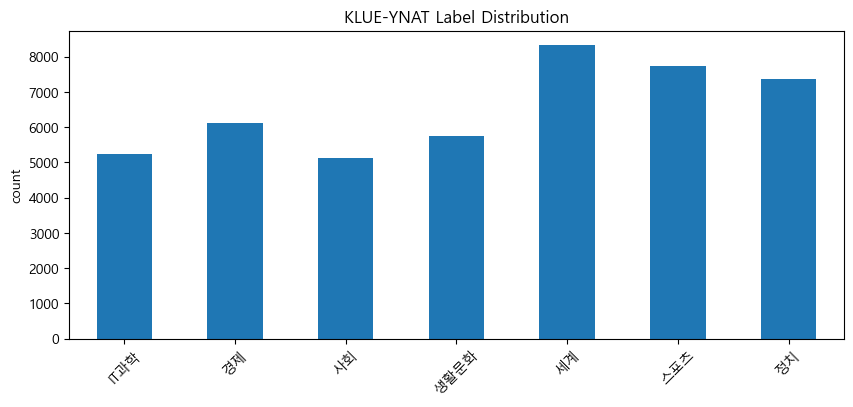

In [20]:
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in id2label.items()}

print(id2label)
print(label2id)

label_counts = train_df['label'].value_counts().sort_index()
label_counts.index = [id2label[i] for i in label_counts.index]

print(label_counts)

plt.figure(figsize=(10, 4))
label_counts.plot(kind='bar')
plt.title('KLUE-YNAT Label Distribution')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.show()

## 4. 실습용 데이터 샘플링하기

전체 데이터를 모두 사용하면 학습 시간이 오래 걸릴 수 있다. 실습에서는 일부 데이터만 사용한다.

1. train 데이터에서 3000개 샘플링하기
2. validation 데이터에서 1000개 샘플링하기
3. `random_state=42`로 설정하기
4. 샘플링된 데이터 크기 확인하기

In [8]:
train_sample = train_df.sample(n=3000, random_state=42).reset_index(drop=True)
val_sample = val_df.sample(n=1000, random_state=42).reset_index(drop=True)

print(train_sample.shape)
print(val_sample.shape)

display(train_sample.head())

(3000, 2)
(1000, 2)


,title,label
0,한미 연구진 스스로 광합성하는 인공세포 제작 성공,0
1,터키 IS 가담 후 조직원 모집 외국인 4명 체포,4
2,사우디 홍해상 폭발 이란 유조선 조력 시도…이란은 부인종합,4
3,알리 호날두 넘어설 재목…공격포인트 40개 압도적,5
4,마니커 140억원 제3자배정 유상증자 결정,1


## 5. BERT Tokenizer 준비하기

1. 모델 이름을 `klue/bert-base`로 설정하기
2. `AutoTokenizer.from_pretrained()`로 tokenizer 불러오기
3. 뉴스 제목 하나를 토큰화하기
4. 토큰과 토큰 id를 함께 확인하기

In [9]:
model_name = 'klue/bert-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)

sample_title = train_sample.loc[0, 'title']
print(sample_title)

sample_tokens = tokenizer.tokenize(sample_title)
sample_ids = tokenizer.encode(sample_title)

print(sample_tokens)
print(sample_ids)
print(tokenizer.convert_ids_to_tokens(sample_ids))

한미 연구진 스스로 광합성하는 인공세포 제작 성공
['한미', '연구', '##진', '스스로', '광', '##합성', '##하', '##는', '인공', '##세포', '제작', '성공']
[2, 7608, 3692, 2043, 4201, 609, 29689, 2205, 2259, 6013, 9200, 4271, 3920, 3]
['[CLS]', '한미', '연구', '##진', '스스로', '광', '##합성', '##하', '##는', '인공', '##세포', '제작', '성공', '[SEP]']


## 6. 데이터 토큰화하기

1. train 제목과 validation 제목을 리스트로 변환하기
2. 라벨을 리스트로 변환하기
3. `padding=True`, `truncation=True`, `max_length=64`를 적용해 토큰화하기
4. 토큰화 결과의 key 확인하기
5. `input_ids`, `attention_mask`의 shape 확인하기

In [10]:
X_train = train_sample['title'].tolist()
y_train = train_sample['label'].tolist()

X_val = val_sample['title'].tolist()
y_val = val_sample['label'].tolist()

train_encodings = tokenizer(
    X_train,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors='pt'
)

val_encodings = tokenizer(
    X_val,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors='pt'
)

print(train_encodings.keys())
print(train_encodings['input_ids'].shape)
print(train_encodings['attention_mask'].shape)
print(val_encodings['input_ids'].shape)
print(val_encodings['attention_mask'].shape)

KeysView({'input_ids': tensor([[    2,  7608,  3692,  ...,     0,     0,     0],
        [    2,  8506,  8374,  ...,     0,     0,     0],
        [    2, 13713,  1932,  ...,     0,     0,     0],
        ...,
        [    2, 20572, 27181,  ...,     0,     0,     0],
        [    2,  7421,  2121,  ...,     0,     0,     0],
        [    2,    57,  5267,  ...,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])})
torch.Size([3000, 26])
torch.Size([3000, 26])
torch.Size([1000, 26])
torch.Size([1000, 26])


## 7. 토큰화 결과 점검하기

1. 하나의 뉴스 제목을 선택하기
2. 원문 제목 확인하기
3. `input_ids`를 다시 토큰으로 변환하기
4. `attention_mask` 확인하기
5. 라벨 id와 라벨 이름 확인하기

In [11]:
index = 0

tokens = tokenizer.convert_ids_to_tokens(train_encodings['input_ids'][index])
attention_mask = train_encodings['attention_mask'][index].numpy()
label_id = y_train[index]

print('원문:', X_train[index])
print('라벨:', label_id, id2label[label_id])

pd.DataFrame({
    'token': tokens,
    'input_id': train_encodings['input_ids'][index].numpy(),
    'attention_mask': attention_mask
}).head(20)

원문: 한미 연구진 스스로 광합성하는 인공세포 제작 성공
라벨: 0 IT과학


,token,input_id,attention_mask
0,[CLS],2,1
1,한미,7608,1
2,연구,3692,1
3,##진,2043,1
4,스스로,4201,1
5,광,609,1
6,##합성,29689,1
7,##하,2205,1
8,##는,2259,1
9,인공,6013,1


## 8. TensorDataset과 DataLoader 만들기

1. 라벨 리스트를 tensor로 변환하기
2. `TensorDataset`으로 train dataset 만들기
3. `TensorDataset`으로 validation dataset 만들기
4. `DataLoader`를 생성하기
5. 첫 번째 batch의 shape 확인하기

In [12]:
train_labels = torch.tensor(y_train, dtype=torch.long)
val_labels = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(
    train_encodings['input_ids'],
    train_encodings['attention_mask'],
    train_labels
)

val_dataset = TensorDataset(
    val_encodings['input_ids'],
    val_encodings['attention_mask'],
    val_labels
)

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

batch = next(iter(train_loader))
print(batch[0].shape)
print(batch[1].shape)
print(batch[2].shape)

torch.Size([16, 26])
torch.Size([16, 26])
torch.Size([16])


## 9. BERT 분류 모델 준비하기

1. `AutoModelForSequenceClassification`으로 모델 불러오기
2. `num_labels`를 라벨 개수로 설정하기
3. `id2label`, `label2id`를 모델에 전달하기
4. GPU 사용 가능 여부를 확인하고 device 설정하기
5. 모델을 device로 이동하기

In [13]:
num_labels = len(label_names)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

device

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


device(type='cpu')

## 10. Optimizer와 Scheduler 설정하기

1. AdamW optimizer를 생성하기
2. learning rate는 `2e-5`로 설정하기
3. epoch는 1로 설정하기
4. 전체 학습 step 수 계산하기
5. linear scheduler 생성하기

In [14]:
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

epochs = 1
total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print('total_steps:', total_steps)

total_steps: 188


## 11. 모델 학습하기

1. 모델을 train mode로 설정하기
2. batch 데이터를 device로 이동하기
3. 모델에 `input_ids`, `attention_mask`, `labels` 전달하기
4. loss를 계산하고 역전파하기
5. gradient clipping 적용하기
6. optimizer와 scheduler를 업데이트하기
7. epoch별 평균 loss를 출력하기

In [15]:
for epoch in range(epochs):
    model.train()
    total_loss = 0

    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}')

    for batch in progress_bar:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(train_loader)
    print(f'Epoch {epoch + 1} Average Loss: {avg_loss:.4f}')

Epoch 1:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1 Average Loss: 0.8349


## 12. 검증 데이터 평가하기

1. 모델을 eval mode로 설정하기
2. validation loader를 순회하며 예측값 구하기
3. `argmax`로 예측 라벨 구하기
4. accuracy 출력하기
5. classification report 출력하기

In [16]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc='Validation'):
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
print('Accuracy:', accuracy)
print()
print(classification_report(
    all_labels,
    all_preds,
    target_names=label_names
))

Validation:   0%|          | 0/63 [00:00<?, ?it/s]

Accuracy: 0.799

              precision    recall  f1-score   support

        IT과학       0.71      0.82      0.76        65
          경제       0.79      0.84      0.81       158
          사회       0.90      0.69      0.78       408
        생활문화       0.75      0.89      0.82       149
          세계       0.79      0.88      0.83        84
         스포츠       0.83      0.98      0.90        51
          정치       0.66      0.86      0.74        85

    accuracy                           0.80      1000
   macro avg       0.77      0.85      0.81      1000
weighted avg       0.81      0.80      0.80      1000



## 13. 직접 입력한 뉴스 제목 예측하기

1. 새 뉴스 제목 리스트 만들기
2. 예측 함수를 작성하기
3. 각 문장에 대해 예측 라벨과 확률 출력하기
4. 예측 결과가 타당한지 확인하기

In [17]:
def predict_topic(texts, model, tokenizer, max_length=64):
    if isinstance(texts, str):
        texts = [texts]

    model.eval()

    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )

    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_ids = torch.argmax(probs, dim=1)

    results = []
    for text, pred_id, prob in zip(texts, pred_ids.cpu().numpy(), probs.cpu().numpy()):
        results.append({
            'title': text,
            'pred_label_id': int(pred_id),
            'pred_label': id2label[int(pred_id)],
            'score': float(prob[pred_id])
        })

    return pd.DataFrame(results)

new_titles = [
    '정부가 청년 주거 지원 정책을 확대하기로 했다',
    '삼성전자가 차세대 반도체 기술을 공개했다',
    '프로야구 개막전에서 홈런이 쏟아졌다',
    '환율 상승으로 수출 기업의 실적 기대감이 커지고 있다',
    '해외 유명 미술관 전시가 서울에서 열린다'
]

predict_topic(new_titles, model, tokenizer)

,title,pred_label_id,pred_label,score
0,정부가 청년 주거 지원 정책을 확대하기로 했다,2,사회,0.440254
1,삼성전자가 차세대 반도체 기술을 공개했다,0,IT과학,0.607457
2,프로야구 개막전에서 홈런이 쏟아졌다,5,스포츠,0.908475
3,환율 상승으로 수출 기업의 실적 기대감이 커지고 있다,1,경제,0.848067
4,해외 유명 미술관 전시가 서울에서 열린다,3,생활문화,0.814107


## 14. 모델과 토크나이저 저장 및 로드하기

1. fine-tuning한 모델 저장하기
2. tokenizer 저장하기
3. 저장된 모델과 tokenizer 다시 불러오기
4. 불러온 모델로 새 문장 예측하기

In [18]:
save_dir = 'ynat_bert_topic_model'

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

loaded_tokenizer = AutoTokenizer.from_pretrained(save_dir)
loaded_model = AutoModelForSequenceClassification.from_pretrained(save_dir)
loaded_model = loaded_model.to(device)

predict_topic(new_titles, loaded_model, loaded_tokenizer)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,title,pred_label_id,pred_label,score
0,정부가 청년 주거 지원 정책을 확대하기로 했다,2,사회,0.440254
1,삼성전자가 차세대 반도체 기술을 공개했다,0,IT과학,0.607457
2,프로야구 개막전에서 홈런이 쏟아졌다,5,스포츠,0.908475
3,환율 상승으로 수출 기업의 실적 기대감이 커지고 있다,1,경제,0.848067
4,해외 유명 미술관 전시가 서울에서 열린다,3,생활문화,0.814107
